### Ekonometrický projekt — LS 2025/2026
**Analýza mzdovej štruktúry pracovníkov (Mincerov model)** | wage1 (Wooldridge, n=526)

#### Načítanie dát

In [ ]:
# Mincerov mzdový model — dataset wage1 z balíka wooldridge
# Y  = lwage  (log hodinovej mzdy, log USD/h)
# X1 = educ   (roky vzdelania)
# X2 = exper  (roky pracovnych skusenosti)
# X3 = tenure (roky u sucasneho zamestnavatela)
# X4 = numdep (pocet zavislych osob v domacnosti)
library(wooldridge)
data(wage1)
df <- wage1
head(df[, c("lwage","educ","exper","tenure","numdep")])
cat("Pocet riadkov:", nrow(df), "| Pocet stlpcov:", ncol(df), "\n")

,lwage,educ,exper,tenure,numdep
,<dbl>,<int>,<int>,<int>,<int>
1,1.131402,11,2,0,2
2,1.175573,12,22,2,3
3,1.098612,11,2,0,2
4,1.791759,8,44,28,0
5,1.667707,12,7,2,1
6,2.169054,16,9,8,0


Pocet riadkov: 526 | Pocet stlpcov: 24 


#### Exploratorná analýza — vzťah X vs. lwage

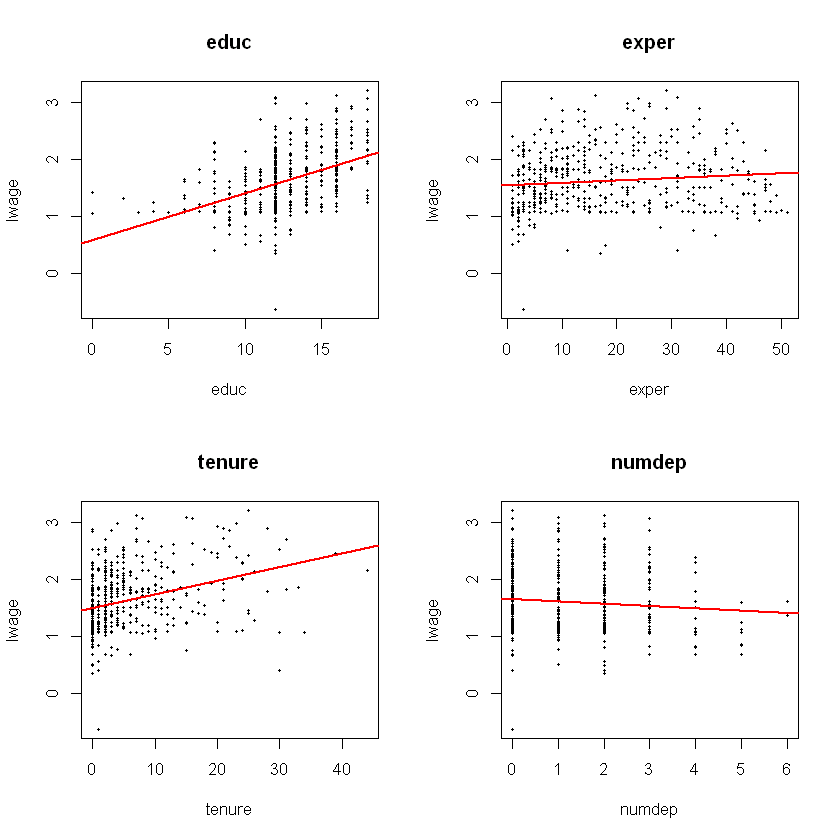

In [121]:
# Scatter ploty regresorov oproti Y
regressors <- c("educ","exper","tenure","numdep")

par(mfrow=c(2,2))
for (col in regressors) {
  plot(df[[col]], df$lwage, pch=19, cex=0.4,
       xlab=col, ylab="lwage", main=col)
  abline(lm(df$lwage ~ df[[col]]), col="red", lwd=2)
}
par(mfrow=c(1,1))

#### Gridsearch: log-transformácie regresorov (16 kombinácií)

In [122]:
# Pre kazdy regresor volime: povodna vs. log1p(x) — 2^4 = 16 kombinacii
# log1p = log(1+x), funguje aj pre nuly (exper=0, tenure=0, numdep=0)
# Pre kazdu kombinaciu: AIC, R2, KS test normality reziduov

regressors <- c("educ","exper","tenure","numdep")
n_reg <- length(regressors)

results <- data.frame(combo=character(), AIC=numeric(), R2=numeric(),
                      KS_stat=numeric(), KS_p=numeric(), normalita=character(),
                      stringsAsFactors=FALSE)

for (mask in 0:(2^n_reg - 1)) {
  terms <- character(n_reg)
  label <- character(n_reg)
  for (j in 1:n_reg) {
    if (bitwAnd(mask, bitwShiftL(1L, j-1L)) > 0) {
      terms[j] <- paste0("log1p(", regressors[j], ")")
      label[j] <- paste0("log(", regressors[j], ")")
    } else {
      terms[j] <- regressors[j]
      label[j] <- regressors[j]
    }
  }
  formula_str <- paste("lwage ~", paste(terms, collapse=" + "))
  m   <- lm(as.formula(formula_str), data=df)
  n   <- nrow(df)
  k   <- length(coef(m))
  rss <- sum(residuals(m)^2)
  aic <- n * log(rss/n) + 2*k
  r2  <- summary(m)$r.squared
  eps <- residuals(m)
  ks  <- suppressWarnings(ks.test(eps, "pnorm", mean=0, sd=sqrt(var(eps))))
  results <- rbind(results, data.frame(
    combo    = paste(label, collapse=" | "),
    AIC      = round(aic, 2),
    R2       = round(r2, 4),
    KS_stat  = round(ks$statistic, 4),
    KS_p     = round(ks$p.value, 4),
    normalita = ifelse(ks$p.value >= 0.05, "OK", "FAIL"),
    stringsAsFactors = FALSE
  ))
}

results <- results[order(results$AIC), ]
cat("Top 10 kombinacii podla AIC:\n")
print(head(results[, c("AIC","R2","KS_p","normalita","combo")], 10), row.names=FALSE)
cat("\nNajlepsia kombinacia:\n", results$combo[1], "\n")
cat("Normalne rezidua (KS p>=0.05):", sum(results$normalita=="OK"), "z", nrow(results), "kombinacii\n")

Top 10 kombinacii podla AIC:
     AIC     R2   KS_p normalita
 -882.61 0.3502 0.3489        OK
 -882.60 0.3502 0.3705        OK
 -875.35 0.3412 0.4288        OK
 -875.35 0.3412 0.4313        OK
 -867.51 0.3313 0.3150        OK
 -867.49 0.3313 0.3233        OK
 -856.03 0.3165 0.3880        OK
 -856.02 0.3165 0.3680        OK
 -830.47 0.2825 0.1355        OK
 -830.37 0.2824 0.1323        OK
                                              combo
           educ | log(exper) | log(tenure) | numdep
      educ | log(exper) | log(tenure) | log(numdep)
                educ | log(exper) | tenure | numdep
           educ | log(exper) | tenure | log(numdep)
                educ | exper | log(tenure) | numdep
           educ | exper | log(tenure) | log(numdep)
                educ | exper | tenure | log(numdep)
                     educ | exper | tenure | numdep
      log(educ) | log(exper) | log(tenure) | numdep
 log(educ) | log(exper) | log(tenure) | log(numdep)

Najlepsia kombinacia:
 educ | log(e

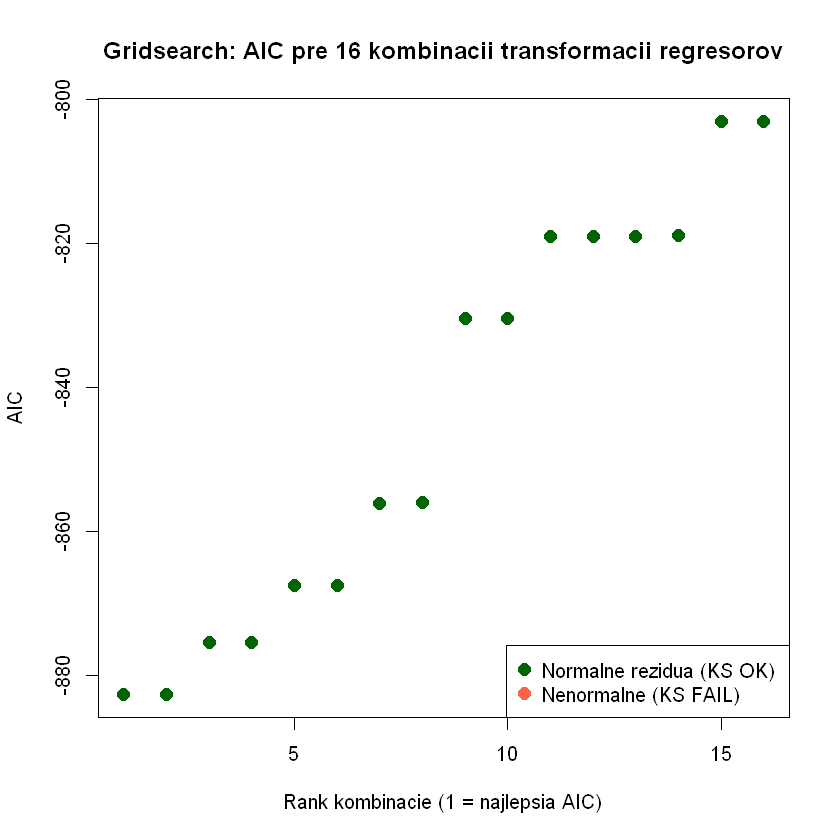

In [123]:
# Vizualizacia gridsearch — AIC pre 16 kombinacii, farebne podla normality
cols <- ifelse(results$normalita == "OK", "darkgreen", "tomato")
plot(seq_along(results$AIC), results$AIC,
     pch=19, col=cols, cex=1.4,
     xlab="Rank kombinacie (1 = najlepsia AIC)", ylab="AIC",
     main="Gridsearch: AIC pre 16 kombinacii transformacii regresorov")
legend("bottomright",
       legend=c("Normalne rezidua (KS OK)", "Nenormalne (KS FAIL)"),
       col=c("darkgreen","tomato"), pch=19, pt.cex=1.4)

#### Povinná úloha — OLS odhad parametrov

In [124]:
################ Priprava premennych ################
Y <- df$lwage
n <- nrow(df)

X <- cbind(1,
           df$educ,
           df$exper,
           df$tenure,
           df$numdep)
k <- ncol(X)   # 5 parametrov (intercept + 4 regresorty)

################ OLS odhad ################
betaHAT <- solve(t(X) %*% X) %*% t(X) %*% Y
rownames(betaHAT) <- c("beta0","educ","exper","tenure","numdep")
betaHAT

beta0,0.257392036
educ,0.093191864
exper,0.004259265
tenure,0.022009286
numdep,0.009871662


In [125]:
################ Rozklad suctu stvorcov ################
YhatOLS    <- X %*% betaHAT
epsilonHAT <- Y - YhatOLS

RSS <- sum(epsilonHAT^2)
ESS <- sum((YhatOLS - mean(Y))^2)
TSS <- sum((Y - mean(Y))^2)

cat("RSS =", round(RSS,4), "\n")
cat("ESS =", round(ESS,4), "\n")
cat("TSS =", round(TSS,4), "\n")
cat("RSS + ESS == TSS:", isTRUE(all.equal(RSS+ESS, TSS)), "\n")

################ Odhad sigma^2 a R^2 ################
s2 <- RSS / (n - k)
cat("sigma2_hat =", round(s2,4), "| sigma_hat =", round(sqrt(s2),4), "log(USD/h)\n")

R2     <- ESS / TSS
adj_R2 <- 1 - (RSS/(n-k)) / (TSS/(n-1))
cat("R2 =", round(R2,4), "| adj.R2 =", round(adj_R2,4), "\n")

RSS = 101.3793 
ESS = 46.9505 
TSS = 148.3298 
RSS + ESS == TSS: TRUE 
sigma2_hat = 0.1946 | sigma_hat = 0.4411 log(USD/h)
R2 = 0.3165 | adj.R2 = 0.3113 


In [126]:
# Porovnanie s lm() — kontrola spravnosti manualneho vypoctu
MODEL <- lm(lwage ~ educ + exper + tenure + numdep, data=df)
summary(MODEL)


Call:
lm(formula = lwage ~ educ + exper + tenure + numdep, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.04536 -0.29037 -0.03488  0.29086  1.42843 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.257392   0.112794   2.282   0.0229 *  
educ        0.093192   0.007566  12.318  < 2e-16 ***
exper       0.004259   0.001738   2.450   0.0146 *  
tenure      0.022009   0.003097   7.107 3.92e-12 ***
numdep      0.009872   0.015763   0.626   0.5314    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.4411 on 521 degrees of freedom
Multiple R-squared:  0.3165,	Adjusted R-squared:  0.3113 
F-statistic: 60.32 on 4 and 521 DF,  p-value: < 2.2e-16


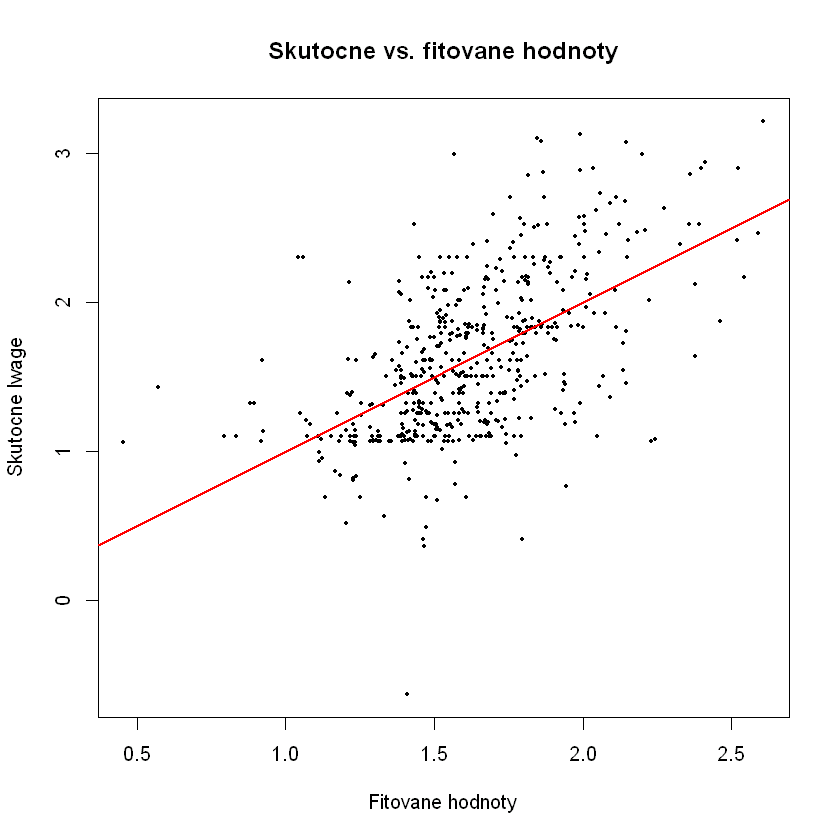

In [127]:
# Skutocne vs. fitovane hodnoty
plot(fitted(MODEL), df$lwage, pch=19, cex=0.4,
     xlab="Fitovane hodnoty", ylab="Skutocne lwage",
     main="Skutocne vs. fitovane hodnoty")
abline(0, 1, col="red", lwd=2)

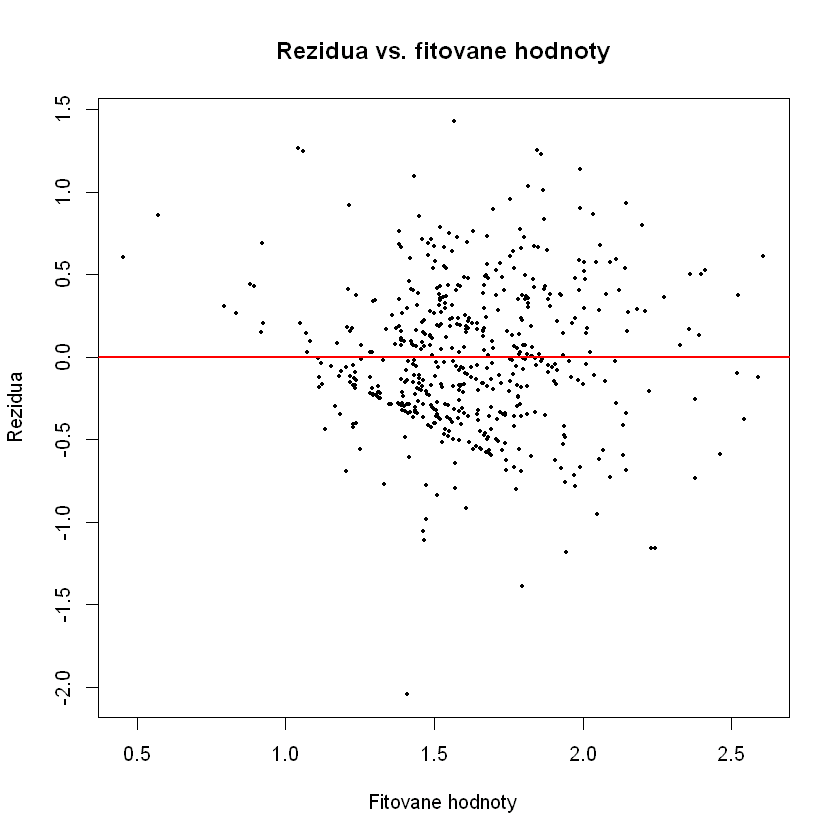

In [128]:
# Rezidua vs. fitovane hodnoty
plot(fitted(MODEL), residuals(MODEL), pch=19, cex=0.4,
     xlab="Fitovane hodnoty", ylab="Rezidua",
     main="Rezidua vs. fitovane hodnoty")
abline(h=0, col="red", lwd=2)

#### Test normality reziduálov
Predpoklad modelu: εᵢ ~ N(0, σ²)

In [129]:
################ KS test normality reziduálov ################
epsilonHAT <- residuals(MODEL)

ks_res <- suppressWarnings(
  ks.test(epsilonHAT, "pnorm", mean=0, sd=sqrt(var(epsilonHAT)))
)
cat("KS test reziduálov:\n")
cat("  KS statistika =", round(ks_res$statistic, 4), "\n")
cat("  p-hodnota     =", round(ks_res$p.value, 6), "\n")
if (ks_res$p.value >= 0.05) {
  cat("  => H0 NEZAMIETAME: rezidua su normalne\n")
} else {
  cat("  => H0 ZAMIETAME: rezidua nie su normalne\n")
}

KS test reziduálov:
  KS statistika = 0.04 
  p-hodnota     = 0.368036 
  => H0 NEZAMIETAME: rezidua su normalne


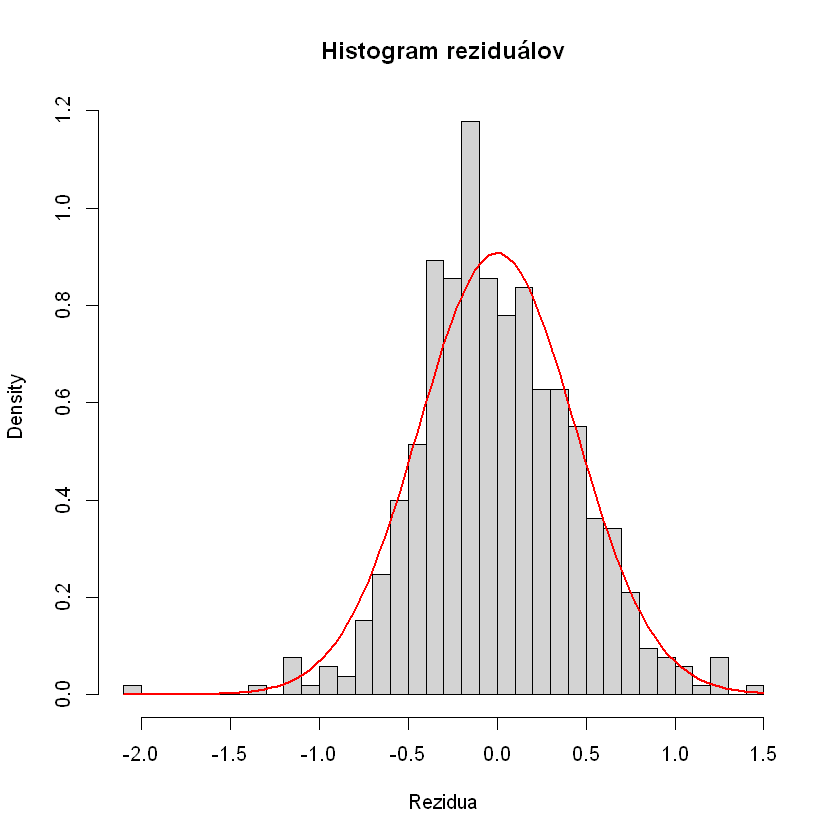

In [130]:
# Histogram reziduálov s normalnou hustotou
hist(epsilonHAT, breaks=25, freq=FALSE,
     xlab="Rezidua", main="Histogram reziduálov")
curve(dnorm(x, mean=0, sd=sqrt(var(epsilonHAT))), add=TRUE, col="red", lwd=2)

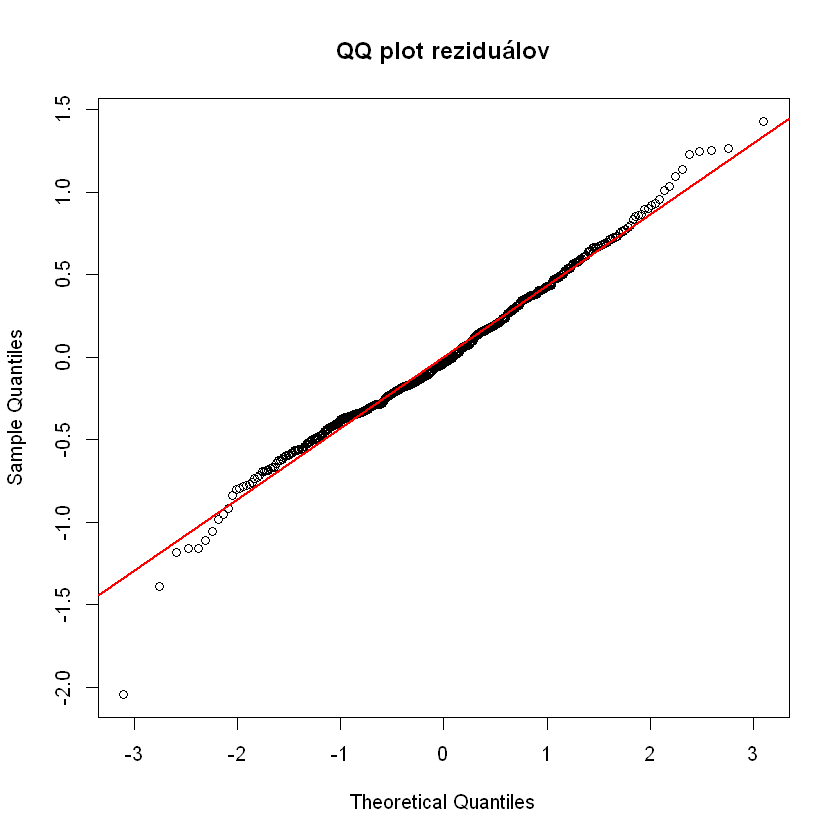

In [131]:
# QQ plot reziduálov
qqnorm(epsilonHAT, main="QQ plot reziduálov")
qqline(epsilonHAT, col="red", lwd=2)

#### Kategória A — Test hypotézy o kontraste
**H₀:** β₂ = β₃ (všeobecné skúsenosti a tenure majú rovnaký vplyv na log mzdu)
**H₁:** β₂ ≠ β₃

In [132]:
################ T-test linearneho kontrastu ################
# H0: beta2 - beta3 = 0  (exper a tenure maju rovnaky vplyv na lwage)
a <- c(0, 0, 1, -1, 0)
r <- 0

t_stat <- (t(a) %*% betaHAT - r) /
          sqrt(s2 * t(a) %*% solve(t(X)%*%X) %*% a)

krit_hodnota <- qt(0.975, df=(n-k))
p_hodnota    <- 2 * (1 - pt(abs(t_stat), df=(n-k)))

cat("Kontrast a\'*betaHAT =", round(t(a) %*% betaHAT, 4),
    "(= beta_exper - beta_tenure)\n")
cat("t statistika =", round(t_stat, 4), "\n")
cat("Kriticka hodnota t(0.975;", n-k,") =", round(krit_hodnota, 4), "\n")
cat("p-hodnota =", round(p_hodnota, 6), "\n")
if (abs(t_stat) > krit_hodnota) {
  cat("=> H0 ZAMIETAME: exper a tenure maju rozdielny vplyv na lwage\n")
} else {
  cat("=> H0 NEZAMIETAME: vplyv exper a tenure na lwage je statisticky rovnaky\n")
}
cat("t^2 =", round(t_stat^2, 4), "(= F pre q=1)\n")

Kontrast a'*betaHAT = -0.0178 (= beta_exper - beta_tenure)
t statistika = -4.1768 
Kriticka hodnota t(0.975; 521 ) = 1.9645 
p-hodnota = 3.5e-05 
=> H0 ZAMIETAME: exper a tenure maju rozdielny vplyv na lwage
t^2 = 17.4457 (= F pre q=1)


#### Kategória B — Predikčné intervaly
Pre pracovníka: educ=12, exper=10, tenure=5, numdep=2
(stredoškolské vzdelanie, 10 rokov praxe, 5 rokov u zamestnávateľa, 2 závislé osoby)

In [133]:
################ Bodovy odhad a predikcny interval ################
alpha <- 0.05

# stredoskolsky vzdelany pracovnik, 10r praxe, 5r tenure, 2 zavisle osoby
x0 <- c(1, 12, 10, 5, 2)

Yhat0 <- t(x0) %*% betaHAT
cat("Bodovy odhad log(mzdy):", round(Yhat0,4), "log(USD/h)\n")
cat("Bodovy odhad mzdy:     ", round(exp(Yhat0),4), "USD/h\n")

# Predikcny interval (obsahuje +1 pod odmocninou)
d_PI <- sqrt(s2) * qt(1-alpha/2, df=n-k) * sqrt(1 + t(x0) %*% solve(t(X)%*%X) %*% x0)
LPI  <- Yhat0 - d_PI
UPI  <- Yhat0 + d_PI
cat("95% predikcny interval (log): [", round(LPI,4), ",", round(UPI,4), "] log(USD/h)\n")
cat("95% predikcny interval (USD): [", round(exp(LPI),4), ",", round(exp(UPI),4), "] USD/h\n")

# IS pre strednu hodnotu E[Y|x0]
d_CI <- sqrt(s2) * qt(1-alpha/2, df=n-k) * sqrt(t(x0) %*% solve(t(X)%*%X) %*% x0)
LCI  <- Yhat0 - d_CI
UCI  <- Yhat0 + d_CI
cat("95% IS pre E[Y|x0] (log): [", round(LCI,4), ",", round(UCI,4), "] log(USD/h)\n")
cat("(PI je sirsi ako IS o", round(d_PI-d_CI,4), "na kazdu stranu)\n")

Bodovy odhad log(mzdy): 1.5481 log(USD/h)
Bodovy odhad mzdy:      4.7024 USD/h
95% predikcny interval (log): [ 0.6799 , 2.4163 ] log(USD/h)
95% predikcny interval (USD): [ 1.9737 , 11.2039 ] USD/h
95% IS pre E[Y|x0] (log): [ 1.4955 , 1.6007 ] log(USD/h)
(PI je sirsi ako IS o 0.8156 na kazdu stranu)


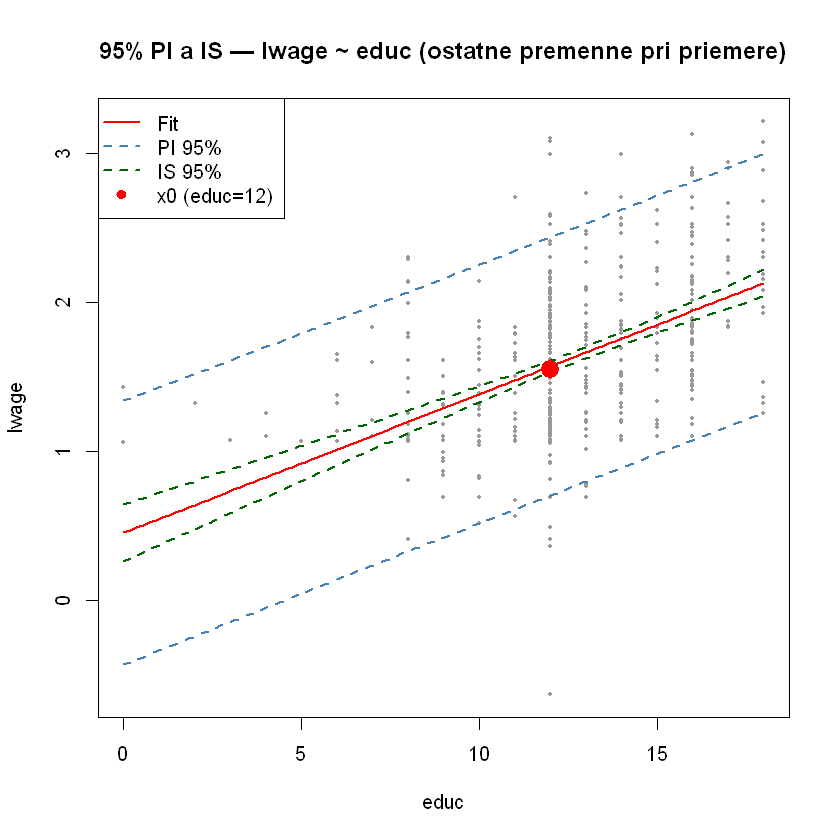

In [134]:
# PI a IS — regresna krivka pozdlz educ, ostatne premenne pri priemere
newdat <- data.frame(
  educ   = seq(min(df$educ), max(df$educ), length.out=100),
  exper  = mean(df$exper),
  tenure = mean(df$tenure),
  numdep = mean(df$numdep)
)
pPI <- predict(MODEL, newdata=newdat, interval="prediction")
pCI <- predict(MODEL, newdata=newdat, interval="confidence")

plot(df$educ, df$lwage, pch=19, cex=0.4, col="grey60",
     xlab="educ", ylab="lwage",
     main="95% PI a IS — lwage ~ educ (ostatne premenne pri priemere)")
lines(newdat$educ, pPI[,"fit"], col="red",       lwd=2)
lines(newdat$educ, pPI[,"lwr"], col="steelblue", lwd=2, lty=2)
lines(newdat$educ, pPI[,"upr"], col="steelblue", lwd=2, lty=2)
lines(newdat$educ, pCI[,"lwr"], col="darkgreen", lwd=2, lty=2)
lines(newdat$educ, pCI[,"upr"], col="darkgreen", lwd=2, lty=2)
points(12, as.numeric(Yhat0), pch=19, cex=2, col="red")
legend("topleft",
       legend=c("Fit", "PI 95%", "IS 95%", "x0 (educ=12)"),
       col=c("red","steelblue","darkgreen","red"),
       lty=c(1,2,2,NA), pch=c(NA,NA,NA,19), lwd=2)

#### Kategória C — Test heteroskedasticity
**H₀:** Var(εᵢ) = σ² ∀i (homoskedasticity)
**H₁:** variance závisí od regresorov

In [135]:
################ Breusch-Pagan test (manualne) ################
epsilonHAT2 <- residuals(MODEL)^2

aux_MODEL <- lm(epsilonHAT2 ~ educ + exper + tenure + numdep, data=df)

R2_aux  <- summary(aux_MODEL)$r.squared
LM_BP   <- n * R2_aux
df_BP   <- k - 1
krit_BP <- qchisq(0.95, df=df_BP)
p_BP    <- 1 - pchisq(LM_BP, df=df_BP)

cat("Breusch-Pagan test:\n")
cat("  LM =", round(LM_BP,4), "\n")
cat("  Kriticka hodnota chi2(0.95;", df_BP,") =", round(krit_BP,4), "\n")
cat("  p-hodnota =", round(p_BP,6), "\n")
if (LM_BP > krit_BP) {
  cat("  => H0 ZAMIETAME: heteroskedasticita detkovana\n")
} else {
  cat("  => H0 NEZAMIETAME\n")
}

Breusch-Pagan test:
  LM = 10.6176 
  Kriticka hodnota chi2(0.95; 4 ) = 9.4877 
  p-hodnota = 0.031215 
  => H0 ZAMIETAME: heteroskedasticita detkovana


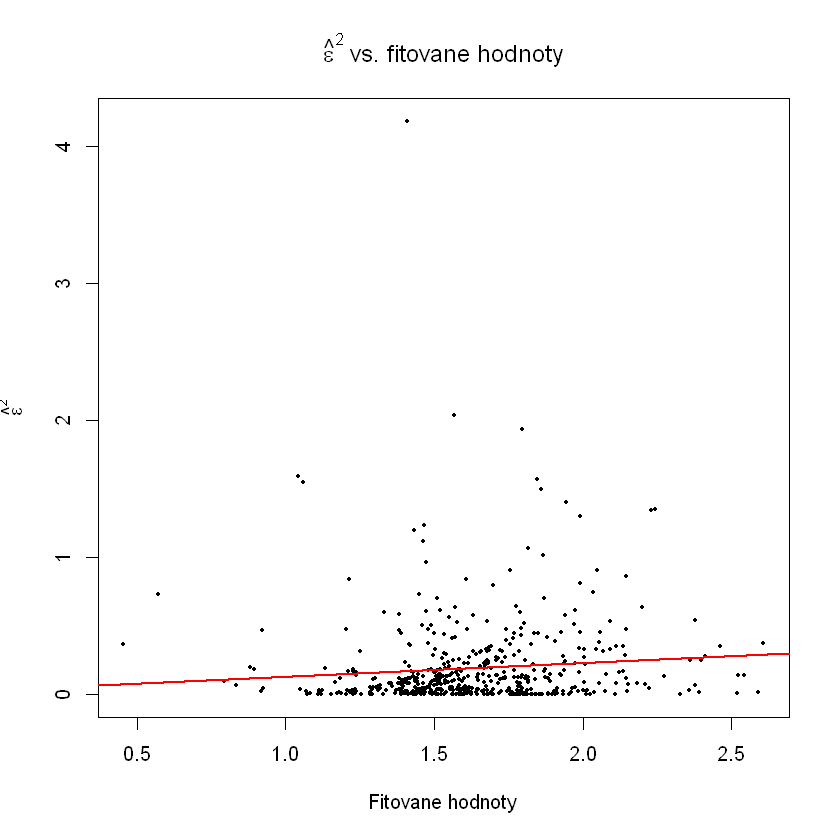

In [136]:
# Rezidua^2 vs. fitovane hodnoty — vizualizacia heteroskedasticity
plot(fitted(MODEL), residuals(MODEL)^2, pch=19, cex=0.4,
     xlab="Fitovane hodnoty", ylab=expression(hat(epsilon)^2),
     main=expression(hat(epsilon)^2 ~ "vs. fitovane hodnoty"))
abline(lm(residuals(MODEL)^2 ~ fitted(MODEL)), col="red", lwd=2)

In [137]:
################ White test a robustne std. chyby ################
library(lmtest)
library(sandwich)

wt <- bptest(MODEL, ~ educ + exper + tenure + numdep +
             I(educ^2) + I(exper^2) + I(tenure^2) + I(numdep^2), data=df)
cat("White test:\n")
print(wt)

cat("\nKoeficienty s HC robustnymi std. chybami:\n")
coeftest(MODEL, vcov=vcovHC(MODEL, type="HC"))

White test:

	studentized Breusch-Pagan test

data:  MODEL
BP = 15.815, df = 8, p-value = 0.04511


Koeficienty s HC robustnymi std. chybami:



t test of coefficients:

             Estimate Std. Error t value  Pr(>|t|)    
(Intercept) 0.2573920  0.1263857  2.0366   0.04220 *  
educ        0.0931919  0.0084563 11.0205 < 2.2e-16 ***
exper       0.0042593  0.0017597  2.4205   0.01584 *  
tenure      0.0220093  0.0037577  5.8571 8.349e-09 ***
numdep      0.0098717  0.0151262  0.6526   0.51429    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


print('GURA NEVONIII')

In [ ]:
print('GURAAA SMRDIIIIII')

[1] "TestA"


In [2]:
print('TestB')

[1] "TestB"


In [ ]:
print('Ahoj :>')  
print('HAHAHA')

In [ ]:
print('JA NESMRDIIIIIIM!!!!!!!!')